In [1]:
%matplotlib inline
import random
import matplotlib.pyplot as plt
import numpy as np 
import struct
from array import array
from os.path import join
import sys
sys.path.append("../")
sys.path.append("../Neural_Network_mod")
from Neural_Network_mod.Neural_Network import *

Functions to load and show the MNIST Dataset

In [2]:

class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)     

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

Load and prepare the MNIST dataset for training and testing: read files, convert to NumPy arrays, flatten images into vectors, and normalize pixel values to [0,1].

In [5]:

input_path = '../input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train_data, y_train_data), (x_test_data, y_test_data) = mnist_dataloader.load_data()

x_train = np.array(x_train_data)
y_train = np.array(y_train_data)
x_test = np.array(x_test_data)
y_test = np.array(y_test_data)


x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Normalization of data
min_val = 0
max_val = 255
x_train = (x_train - min_val) / (max_val - min_val)
x_test = (x_test - min_val) / (max_val - min_val)


Define the Neural Network architecture and optimizer (model setup)

In [6]:

np.random.seed(0)
Network = NeuralNetwork(layers=[
    Dense(x_train.shape[1], 128), LeakyReLU(),
    Dense(128, 128), LeakyReLU(),
    Dense(128, 64), LeakyReLU(),
    Dense(64, 10), Softmax()
])

Network.loss = LossCategoricalCrossentropy()
Network.optimizer = SGDWithDecay(decay=1e-4)




Train the network

In [7]:
History = Network.train(x_train, y_train , 
              epochs=25, 
              validation_ratio=0.2, 
              learning_rate=0.7, 
              batch_size=256)



Epoch   0/25   | Loss: 2.4245, Accuracy: 0.0769 | Val Loss: 2.4316, Val Accuracy: 0.0746
Epoch   1/25   | Loss: 0.3531, Accuracy: 0.9062 | Val Loss: 0.2640, Val Accuracy: 0.9269
Epoch   2/25   | Loss: 0.2207, Accuracy: 0.9453 | Val Loss: 0.1946, Val Accuracy: 0.9461
Epoch   3/25   | Loss: 0.1673, Accuracy: 0.9453 | Val Loss: 0.1860, Val Accuracy: 0.9456
Epoch   4/25   | Loss: 0.2172, Accuracy: 0.9531 | Val Loss: 0.1521, Val Accuracy: 0.9575
Epoch   5/25   | Loss: 0.1874, Accuracy: 0.9766 | Val Loss: 0.1416, Val Accuracy: 0.9613
Epoch   6/25   | Loss: 0.0433, Accuracy: 1.0000 | Val Loss: 0.1303, Val Accuracy: 0.9626
Epoch   7/25   | Loss: 0.0730, Accuracy: 0.9844 | Val Loss: 0.1341, Val Accuracy: 0.9623
Epoch   8/25   | Loss: 0.0877, Accuracy: 0.9844 | Val Loss: 0.1284, Val Accuracy: 0.9637
Epoch   9/25   | Loss: 0.1541, Accuracy: 0.9766 | Val Loss: 0.1222, Val Accuracy: 0.9663
Epoch  10/25   | Loss: 0.1615, Accuracy: 0.9531 | Val Loss: 0.1246, Val Accuracy: 0.9651
Epoch  11/25   | Loss

Plot the training and validation loss curves

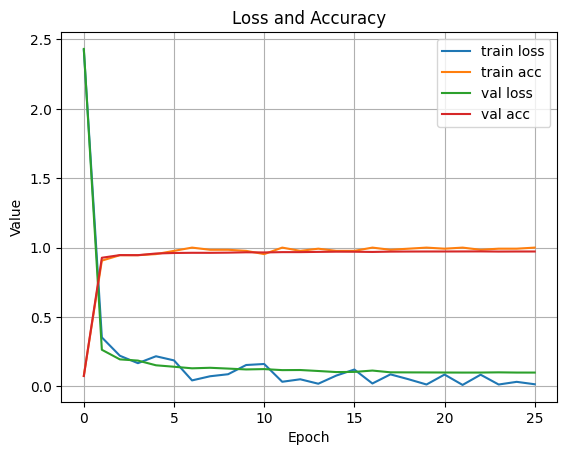

In [8]:
keys = list(History[0].keys())
History_Data = [[d[key] for key in keys] for d in History]
np_History = np.array(History_Data)

Epochs_Data = np_History[:, 0]

if "Loss" in keys:
    loss_Data = np_History[:, 1]
    plt.plot(Epochs_Data, loss_Data, label='train loss')

if "Accuracy" in keys:
    acc_Data = np_History[:, 2]
    plt.plot(Epochs_Data, acc_Data, label='train acc')

if "Val_Loss" in keys:
    val_loss_Data = np_History[:, 3]
    plt.plot(Epochs_Data, val_loss_Data, label='val loss')

if "Val_Accuracy" in keys:
    val_acc_Data = np_History[:, 4]
    plt.plot(Epochs_Data, val_acc_Data, label='val acc')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Loss and Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Evaluate the trained model on test set, collect predictions, and build confusion matrix

In [9]:
test_loss, test_acc = Network.test_batch(x_test,y_test)
all_entries = []
wrong = []
correct = []
for i in range(len(y_test)):
    Output_Label = Network.predict(x_test[i])[0]
    True_Label = y_test[i]
    result = (i , int(Output_Label), int(True_Label))
    if Output_Label != True_Label:
        wrong.append(result)
    else:
        correct.append(result)
    all_entries.append(result)
    

wrong = np.array(wrong)
correct = np.array(correct)
all_entries = np.array(all_entries, dtype=int)

images_wrong_show = []
titles_wrong_show = []


num_classes = 10
Confusion = np.zeros((num_classes, num_classes), dtype=int)
for true_label in range(num_classes):
    for pred_class in range(num_classes):
        Confusion[true_label, pred_class] = np.sum(
            (all_entries[:, 2] == true_label) & (all_entries[:, 1] == pred_class)
        )

Confusion = np.array(Confusion)
total_sum = np.sum(Confusion)

for i in range(0, 5):
    r = random.choice(wrong)
    r_index = r[0]
    images_wrong_show.append(x_test_data[r_index])        
    titles_wrong_show.append(f'Test[{r[0]}] : Prediction = {r[1]} | True = {r[2]}')  




Test summary and display example misclassifications

Test Loss     : 0.0937
Test Accuracy : 0.9742
Total Case    :  10000
Wrong Count   :  258
Correct Count :  9742
confusion matrix of Each Class

5 Wrong Prediction Example:


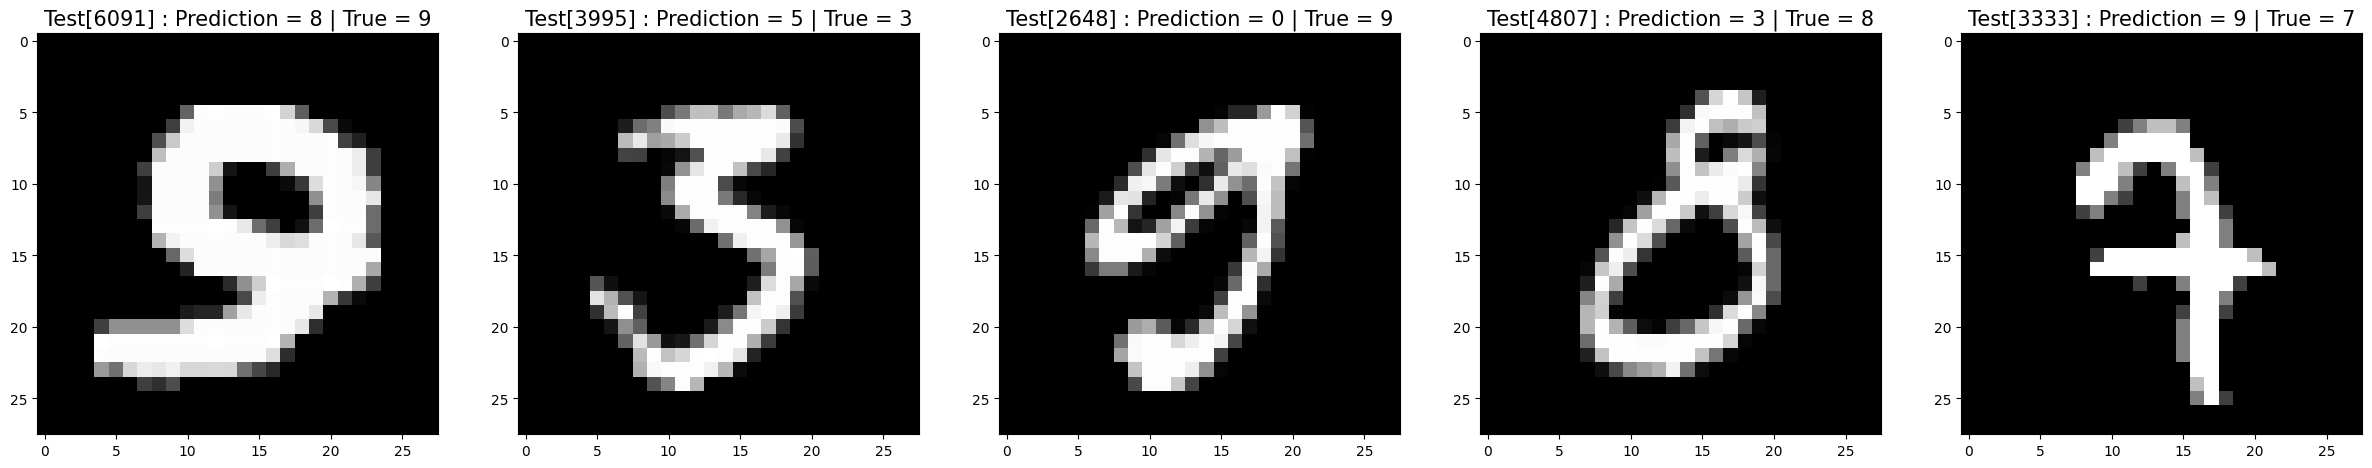

In [10]:

print(f"{'Test Loss':<13} : {test_loss:.4f}")
print(f"{'Test Accuracy':<13} : {test_acc:.4f}")
print(f"{'Total Case':<13} : ",len(y_test))
print(f"{'Wrong Count':<13} : ", len(wrong))
print(f"{'Correct Count':<13} : ", len(correct))
print(f"confusion matrix of Each Class")

print(f"\n5 Wrong Prediction Example:")

show_images(images_wrong_show, titles_wrong_show)





Plot confusion matrix

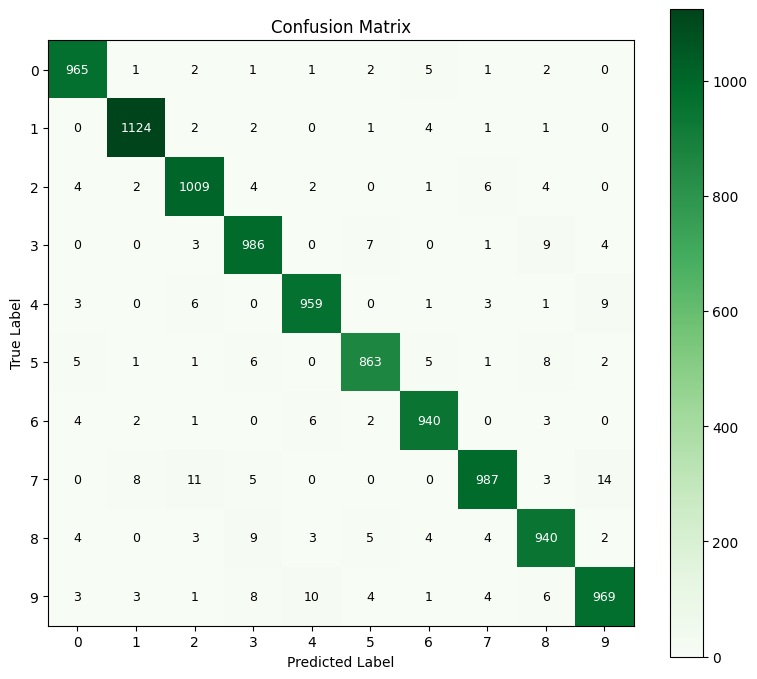

In [11]:
labels = [str(i) for i in range(10)]  

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(Confusion, cmap="Greens", interpolation="nearest")
cbar = fig.colorbar(im, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

thresh = Confusion.max() / 2.
for i in range(Confusion.shape[0]):
    for j in range(Confusion.shape[1]):
        color = "white" if Confusion[i, j] > thresh else "black"
        ax.text(j, i, format(Confusion[i, j], "d"),
                ha="center", va="center", color=color, fontsize=9)

ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()